In [13]:
# --- Data ---

import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- TFT & time series forecasting (PyTorch) ---
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
# from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters  # optional

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Preprocessing & metrics ---
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Utilities ---
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [14]:
# ── Load raw files ─────────────────────────────────────────────────────────────
top50 = pd.read_csv("top50_adjclose_2010_2025.csv", parse_dates=["Date"])
unp   = pd.read_csv("unp_us_d.csv",                 parse_dates=["Date"])
spx   = pd.read_csv("^spx_d.csv",                    parse_dates=["Date"])

top50 = top50[["Date", "AAPL", "JPM", "XOM", "JNJ"]].copy()
unp   = unp[["Date", "Close"]].rename(columns={"Close": "UNP"})
spx   = spx[["Date", "Close"]].rename(columns={"Close": "SPX"})

# ── Merge everything on Date (inner join = common trading days only) ────────────
df = top50.merge(unp, on="Date", how="inner") \
          .merge(spx, on="Date", how="inner")

# ── Filter to 2015-01-01 → last date where ALL sources have data ───────────────
df = df[df["Date"] >= "2015-01-01"].reset_index(drop=True)

df = df.set_index("Date")

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range : 2015-01-02 → 2025-12-30
Trading days: 2765
Columns     : ['AAPL', 'JPM', 'XOM', 'JNJ', 'UNP', 'SPX']
Missing values:
AAPL    0
JPM     0
XOM     0
JNJ     0
UNP     0
SPX     0
dtype: int64
                 AAPL        JPM        XOM        JNJ      UNP      SPX
Date                                                                    
2015-01-02  24.237549  46.511147  57.916904  76.955574  99.4006  2058.20
2015-01-05  23.554741  45.067200  56.332180  76.418091  96.0670  2020.58
2015-01-06  23.556957  43.898647  56.032707  76.042587  94.0529  2002.61


In [15]:
TICKERS = ["AAPL", "JPM", "XOM", "JNJ", "UNP"]

# ── Log returns ────────────────────────────────────────────────────────────────
for t in TICKERS:
    df[f"{t}_ret"] = np.log(df[t] / df[t].shift(1))

df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

# ── Rolling MAs of log returns (per stock only, as per proposal) ───────────────
for t in TICKERS:
    df[f"{t}_MA5"]  = df[f"{t}_ret"].rolling(5).mean()
    df[f"{t}_MA21"] = df[f"{t}_ret"].rolling(21).mean()
    df[f"{t}_MA63"] = df[f"{t}_ret"].rolling(63).mean()

# ── Rolling volatility of log returns (per stock only) ────────────────────────
for t in TICKERS:
    df[f"{t}_VOL5"]  = df[f"{t}_ret"].rolling(5).std()
    df[f"{t}_VOL21"] = df[f"{t}_ret"].rolling(21).std()
    df[f"{t}_VOL63"] = df[f"{t}_ret"].rolling(63).std()

# ── Shared SPX rolling volatility ─────────────────────────────────────────────
df["SPX_VOL21"] = df["SPX_ret"].rolling(21).std()

# ── Drop raw prices (no longer needed) and first 63 rows (NaN warmup) ─────────
price_cols = TICKERS + ["SPX"]
df = df.drop(columns=price_cols)
df = df.iloc[63:].copy()

# ── Reorder columns: SPX shared features first, then per-stock blocks ──────────
spx_cols    = ["SPX_ret", "SPX_VOL21"]
stock_cols  = [f"{t}{s}" for t in TICKERS 
               for s in ["_ret", "_MA5", "_MA21", "_MA63", "_VOL5", "_VOL21", "_VOL63"]]

df = df[spx_cols + stock_cols]

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range  : 2015-04-06 → 2025-12-30
Trading days: 2702
Columns     : ['SPX_ret', 'SPX_VOL21', 'AAPL_ret', 'AAPL_MA5', 'AAPL_MA21', 'AAPL_MA63', 'AAPL_VOL5', 'AAPL_VOL21', 'AAPL_VOL63', 'JPM_ret', 'JPM_MA5', 'JPM_MA21', 'JPM_MA63', 'JPM_VOL5', 'JPM_VOL21', 'JPM_VOL63', 'XOM_ret', 'XOM_MA5', 'XOM_MA21', 'XOM_MA63', 'XOM_VOL5', 'XOM_VOL21', 'XOM_VOL63', 'JNJ_ret', 'JNJ_MA5', 'JNJ_MA21', 'JNJ_MA63', 'JNJ_VOL5', 'JNJ_VOL21', 'JNJ_VOL63', 'UNP_ret', 'UNP_MA5', 'UNP_MA21', 'UNP_MA63', 'UNP_VOL5', 'UNP_VOL21', 'UNP_VOL63']
Missing values:
SPX_ret       0
SPX_VOL21     0
AAPL_ret      0
AAPL_MA5      0
AAPL_MA21     0
AAPL_MA63     0
AAPL_VOL5     0
AAPL_VOL21    0
AAPL_VOL63    0
JPM_ret       0
JPM_MA5       0
JPM_MA21      0
JPM_MA63      0
JPM_VOL5      0
JPM_VOL21     0
JPM_VOL63     0
XOM_ret       0
XOM_MA5       0
XOM_MA21      0
XOM_MA63      0
XOM_VOL5      0
XOM_VOL21     0
XOM_VOL63     0
JNJ_ret       0
JNJ_MA5       0
JNJ_MA21      0
JNJ_MA63      0
JNJ_VOL5      0
JNJ_VOL21    

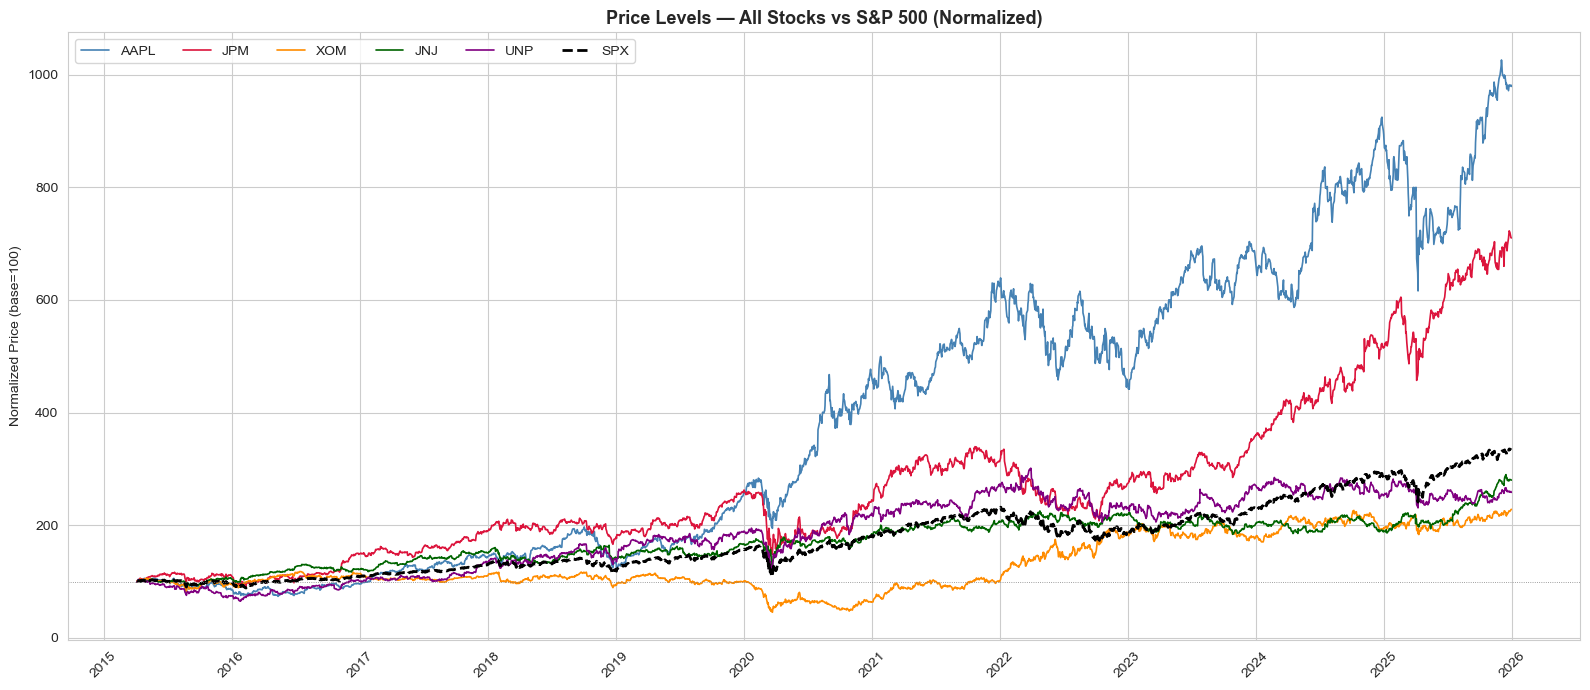

In [16]:
ALL_TICKERS = TICKERS + ["SPX"]

prices_norm = df[[f"{t}_ret" for t in ALL_TICKERS]].cumsum().apply(np.exp) * 100
prices_norm.columns = ALL_TICKERS

fig, ax = plt.subplots(figsize=(16, 7))

colors = {"AAPL":"steelblue", "JPM":"crimson", "XOM":"darkorange",
          "JNJ":"darkgreen",  "UNP":"purple",  "SPX":"black"}

for col in ALL_TICKERS:
    lw = 2.0 if col == "SPX" else 1.2
    ls = "--" if col == "SPX" else "-"
    ax.plot(prices_norm.index, prices_norm[col], label=col,
            color=colors[col], lw=lw, linestyle=ls)

ax.axhline(100, color="grey", lw=0.6, linestyle=":")
ax.set_ylabel("Normalized Price (base=100)", fontsize=10)
ax.set_title("Price Levels — All Stocks vs S&P 500 (Normalized)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=6, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

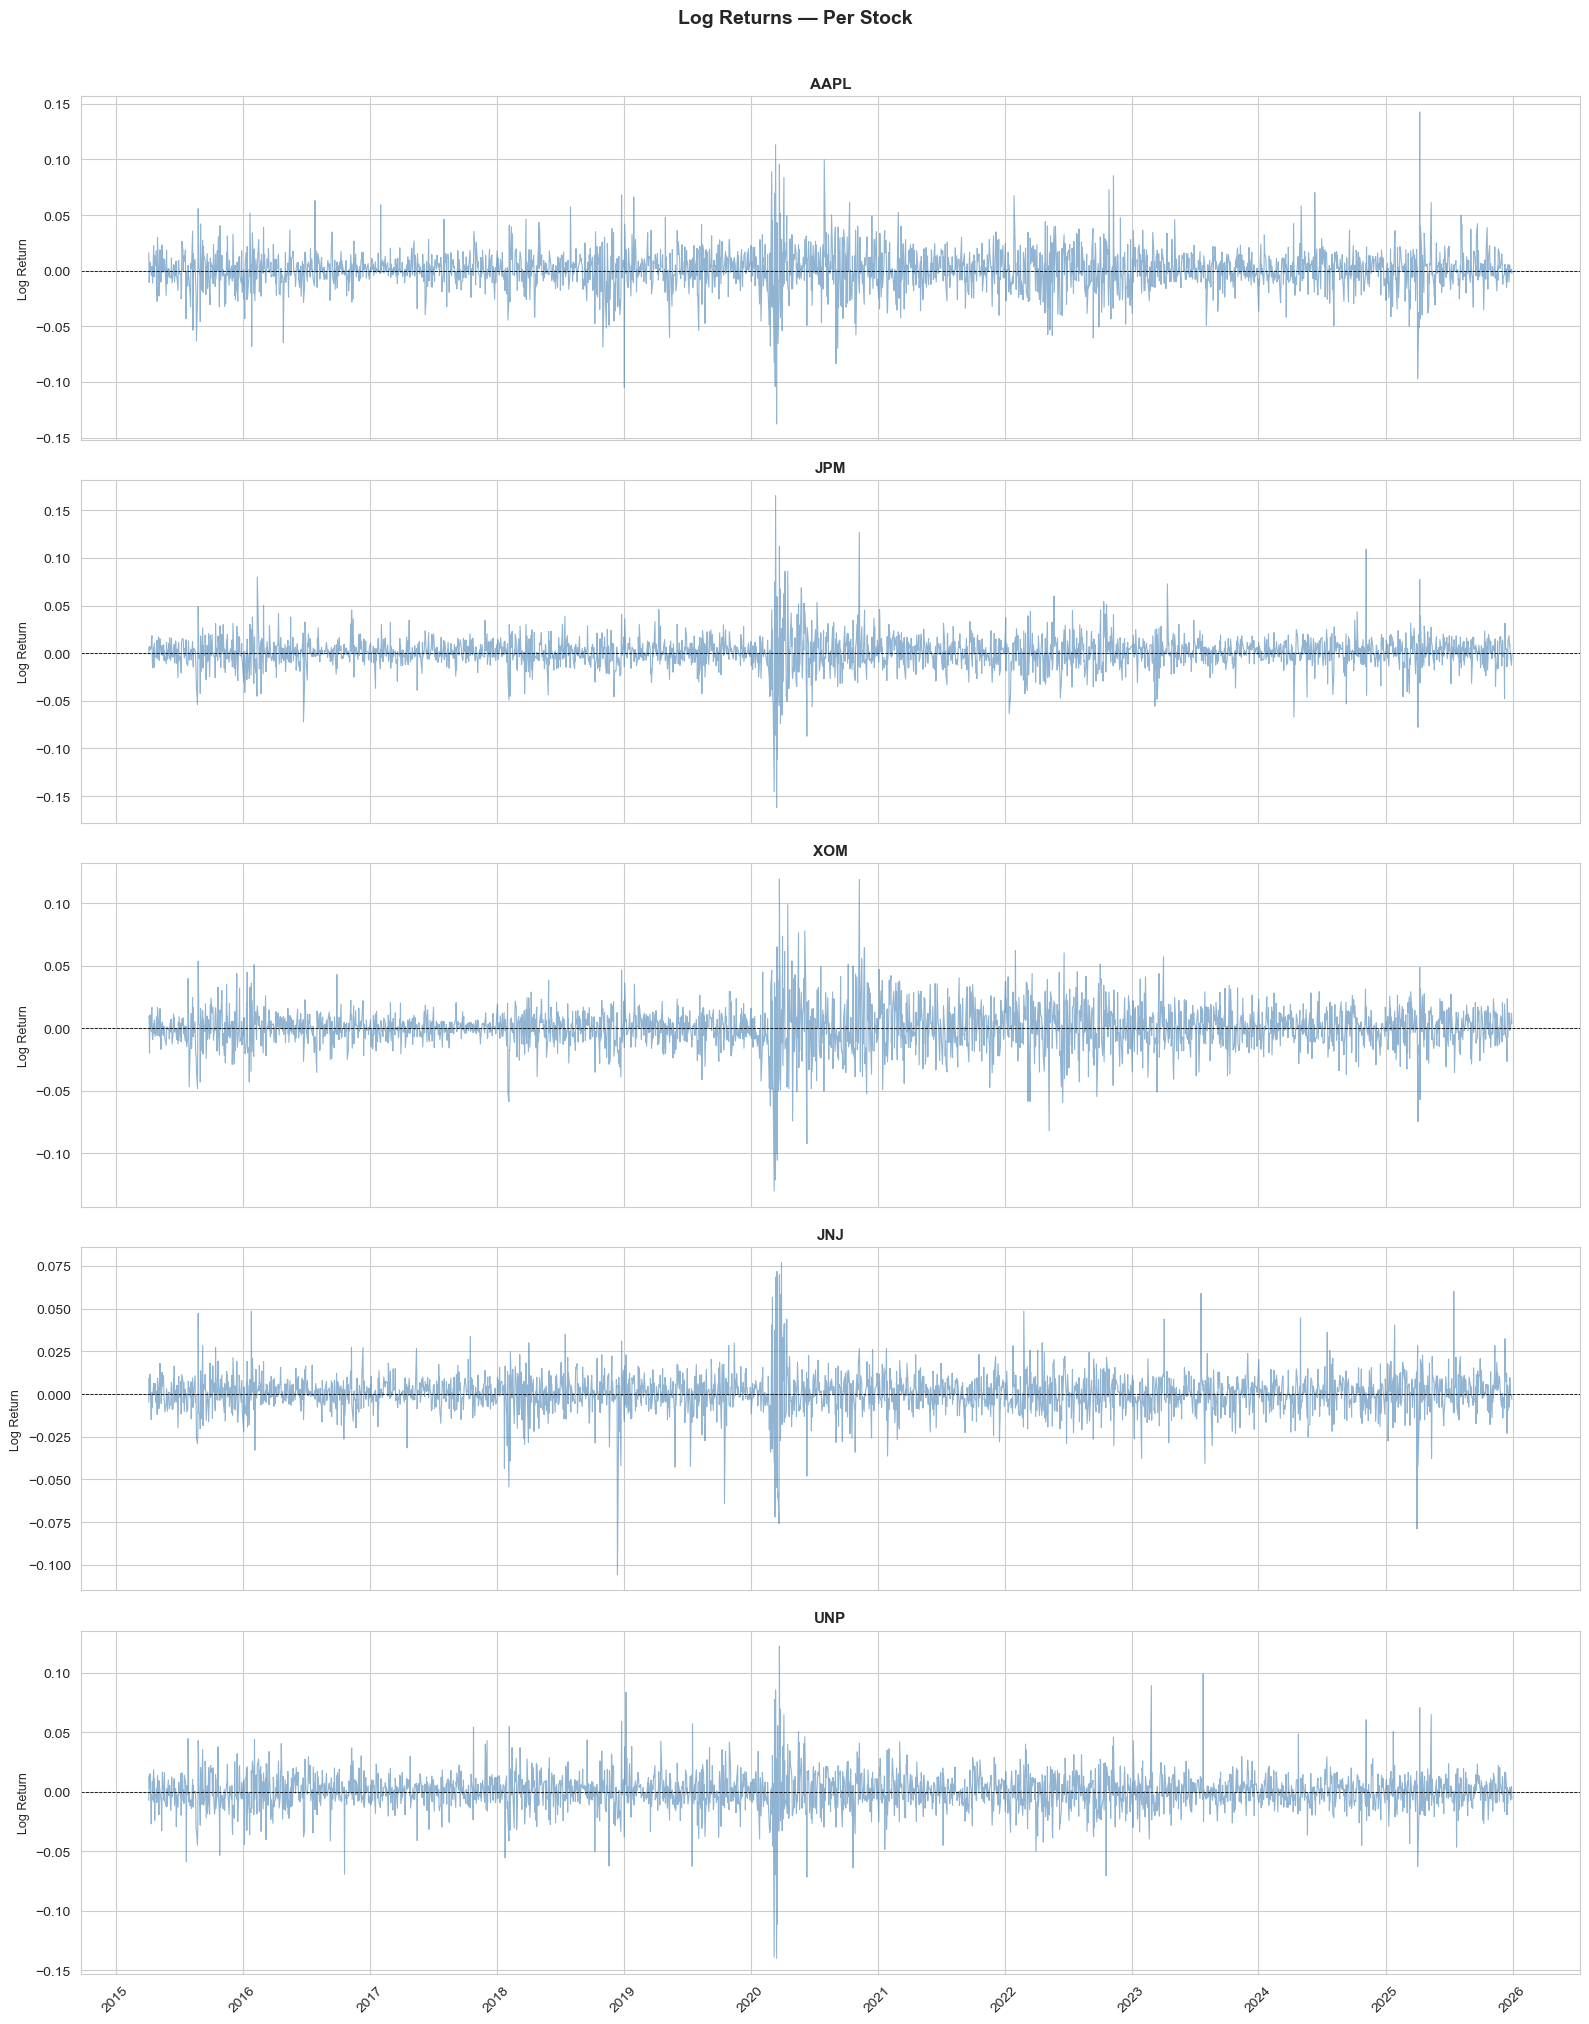

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, t in zip(axes, TICKERS):
    ax.plot(df.index, df[f"{t}_ret"], color="steelblue", alpha=0.6, lw=0.8, label="Log Return")
    ax.axhline(0, color="black", lw=0.6, linestyle="--")
    ax.set_ylabel("Log Return", fontsize=9)
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Log Returns — Per Stock", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDescriptive stats:\n", df.describe())

Shape: (2702, 37)

Descriptive stats:
            SPX_ret    SPX_VOL21     AAPL_ret     AAPL_MA5    AAPL_MA21  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000   
mean      0.000446     0.009458     0.000844     0.000846     0.000849   
std       0.011364     0.006419     0.018181     0.007708     0.003767   
min      -0.127652     0.002185    -0.137708    -0.051618    -0.015928   
25%      -0.003747     0.005775    -0.007270    -0.003376    -0.001389   
50%       0.000710     0.007815     0.000898     0.001260     0.001128   
75%       0.005735     0.011659     0.009841     0.005363     0.003496   
max       0.090895     0.061454     0.142617     0.033803     0.014691   

         AAPL_MA63    AAPL_VOL5   AAPL_VOL21   AAPL_VOL63      JPM_ret  ...  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000  ...   
mean      0.000852     0.015281     0.016443     0.017052     0.000725  ...   
std       0.002142     0.010267     0.007893     0.006478

In [19]:
SECTOR_MAP = {
    "AAPL": "Technology",
    "JPM":  "Financials",
    "XOM":  "Energy",
    "JNJ":  "Healthcare",
    "UNP":  "Industrials",
}

In [20]:
# ── Convert to long format ─────────────────────────────────────────────────────
records = []

for t in TICKERS:
    tmp = pd.DataFrame({
        "date"       : df.index,
        "stock_id"   : t,
        "sector"     : SECTOR_MAP[t],
        "log_return" : df[f"{t}_ret"].values,
        "MA_5"       : df[f"{t}_MA5"].values,
        "MA_21"      : df[f"{t}_MA21"].values,
        "MA_63"      : df[f"{t}_MA63"].values,
        "VOL_5"      : df[f"{t}_VOL5"].values,
        "VOL_21"     : df[f"{t}_VOL21"].values,
        "VOL_63"     : df[f"{t}_VOL63"].values,
        "SP500_ret"  : df["SPX_ret"].values,
        "SP500_VOL21": df["SPX_VOL21"].values,
        "day_of_week": df.index.dayofweek,
        "month"      : df.index.month,
    })
    records.append(tmp)

panel = pd.concat(records, ignore_index=True)
panel = panel.sort_values(["date", "stock_id"]).reset_index(drop=True)

# ── Add global time index ──────────────────────────────────────────────────────
date_to_idx = {d: i for i, d in enumerate(sorted(panel["date"].unique()))}
panel["time_idx"] = panel["date"].map(date_to_idx)

# ── Add train/val/test split ───────────────────────────────────────────────────
T = panel["time_idx"].max()
panel["split"] = pd.cut(
    panel["time_idx"],
    bins=[-1, int(0.70 * T), int(0.85 * T), T],
    labels=["train", "val", "test"]
)

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Shape       : {panel.shape}")
print(f"Date range  : {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"Stocks      : {panel['stock_id'].unique().tolist()}")
print(f"Split counts:\n{panel['split'].value_counts().sort_index()}")
print(panel.head(10))

Shape       : (13510, 16)
Date range  : 2015-04-06 → 2025-12-30
Stocks      : ['AAPL', 'JNJ', 'JPM', 'UNP', 'XOM']
Split counts:
split
train    9455
val      2025
test     2030
Name: count, dtype: int64
        date stock_id       sector  log_return      MA_5     MA_21     MA_63  \
0 2015-04-06     AAPL   Technology    0.016069  0.006545  0.000353  0.002484   
1 2015-04-06      JNJ   Healthcare   -0.004829 -0.002366 -0.001587 -0.000725   
2 2015-04-06      JPM   Financials   -0.000826  0.004391 -0.000874 -0.000416   
3 2015-04-06      UNP  Industrials   -0.007183 -0.003857 -0.005072 -0.001655   
4 2015-04-06      XOM       Energy    0.009798  0.003675 -0.000892 -0.001255   
5 2015-04-07     AAPL   Technology   -0.010578 -0.000571 -0.000222  0.002770   
6 2015-04-07      JNJ   Healthcare    0.009435 -0.002876 -0.000005 -0.000464   
7 2015-04-07      JPM   Financials    0.006264  0.000964  0.000284  0.000184   
8 2015-04-07      UNP  Industrials    0.013556 -0.004162 -0.003674 -0.000898 

In [21]:
# ── 1. Unit test entity isolation ─────────────────────────────────────────────
for t in TICKERS:
    expected = (panel[panel.stock_id == t]["log_return"]
                .rolling(5)
                .mean()
                .reset_index(drop=True))
    actual = panel[panel.stock_id == t]["MA_5"].reset_index(drop=True)
    
    # compare ignoring NaNs at the start
    mask = expected.notna() & actual.notna()
    assert (expected[mask].round(10) == actual[mask].round(10)).all(), \
        f"MA_5 mismatch for {t}"
    print(f"✓ {t} MA_5 entity isolation passed")

print("\nAll unit tests passed.")

✓ AAPL MA_5 entity isolation passed
✓ JPM MA_5 entity isolation passed
✓ XOM MA_5 entity isolation passed
✓ JNJ MA_5 entity isolation passed
✓ UNP MA_5 entity isolation passed

All unit tests passed.


In [22]:
# ── 2. Split boundaries ────────────────────────────────────────────────────────
for split in ["train", "val", "test"]:
    subset = panel[panel.split == split]["date"]
    print(f"{split:5s} : {subset.min().date()} → {subset.max().date()}  ({subset.nunique()} trading days)")

train : 2015-04-06 → 2022-10-05  (1891 trading days)
val   : 2022-10-06 → 2024-05-16  (405 trading days)
test  : 2024-05-17 → 2025-12-30  (406 trading days)


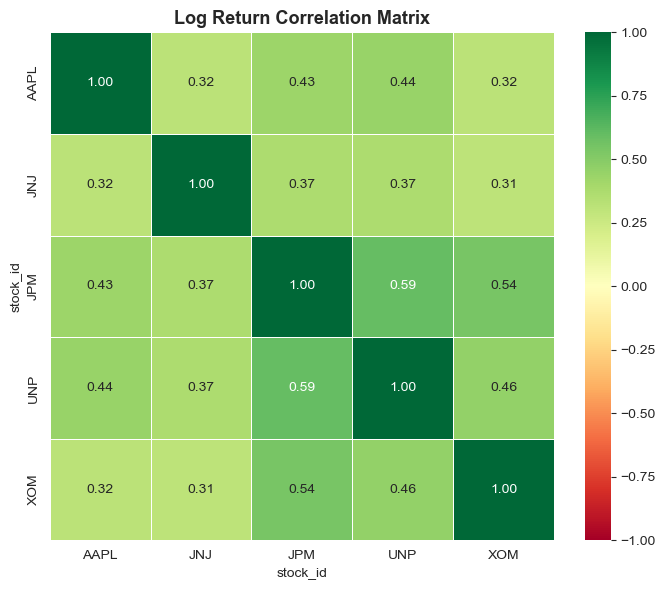

In [23]:
# ── 3. Correlation matrix of log returns ──────────────────────────────────────

ret_wide = panel.pivot(index="date", columns="stock_id", values="log_return")
corr = ret_wide.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Log Return Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

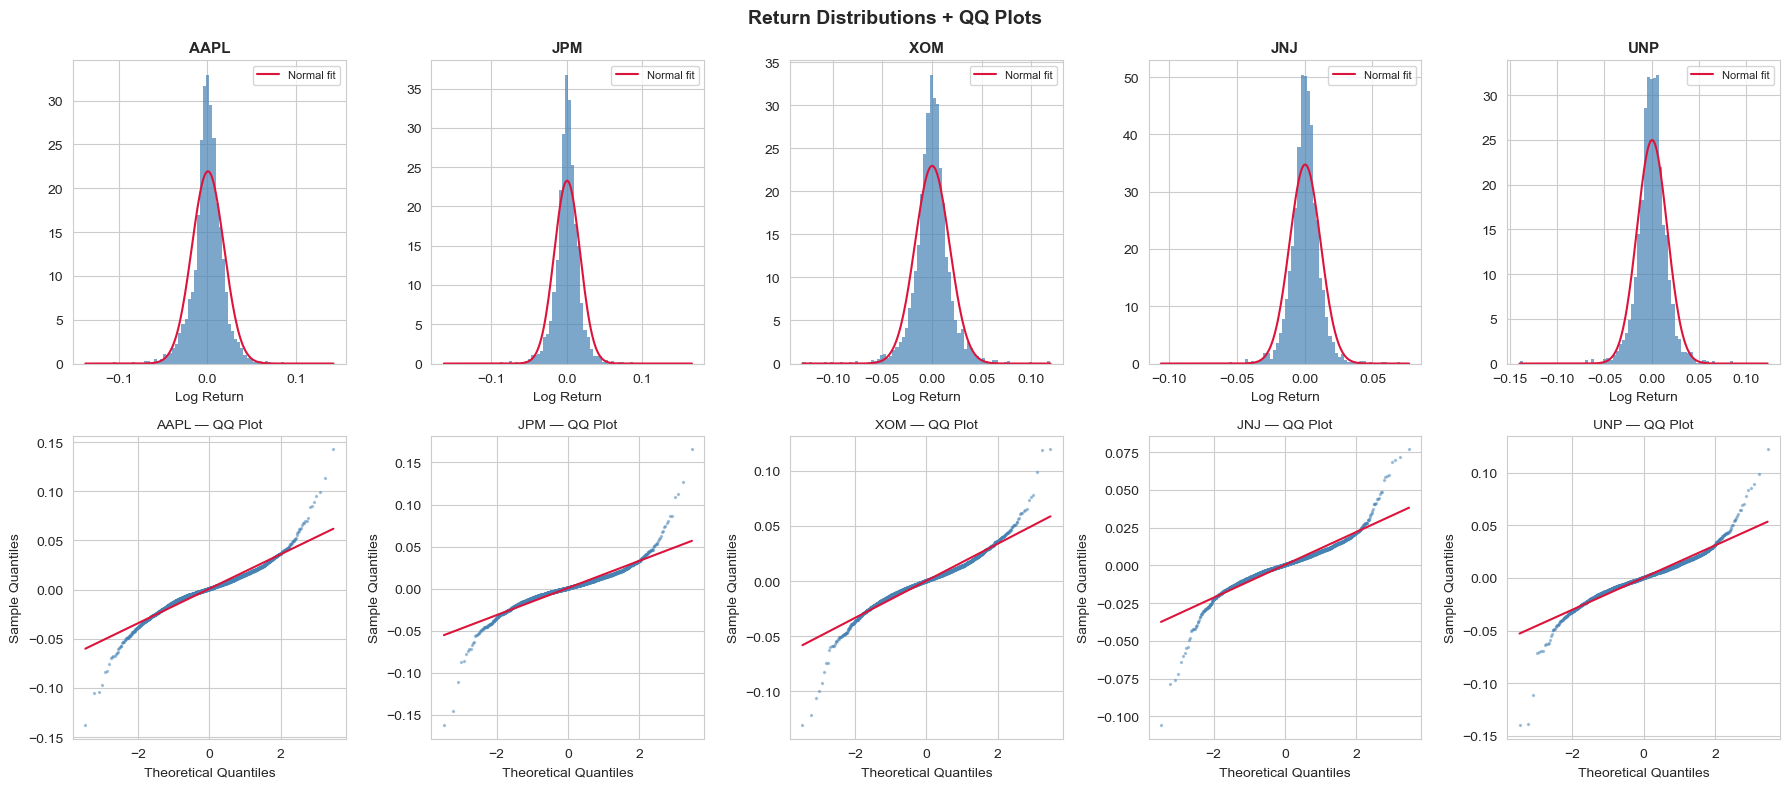

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, t in enumerate(TICKERS):
    rets = panel[panel.stock_id == t]["log_return"].dropna()

    # histogram
    ax = axes[0, i]
    ax.hist(rets, bins=80, color="steelblue", edgecolor="none", alpha=0.7, density=True)
    x = np.linspace(rets.min(), rets.max(), 200)
    ax.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()),
            color="crimson", lw=1.5, label="Normal fit")
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.set_xlabel("Log Return")
    ax.legend(fontsize=8)

    # QQ plot — manual
    ax = axes[1, i]
    osm, osr = stats.probplot(rets, dist="norm")[:2]
    theoretical_q, ordered_vals = osm
    ax.scatter(theoretical_q, ordered_vals, s=2, alpha=0.4, color="steelblue")
    ax.plot(theoretical_q, theoretical_q * osr[0] + osr[1], color="crimson", lw=1.5)
    ax.set_title(f"{t} — QQ Plot", fontsize=10)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

fig.suptitle("Return Distributions + QQ Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

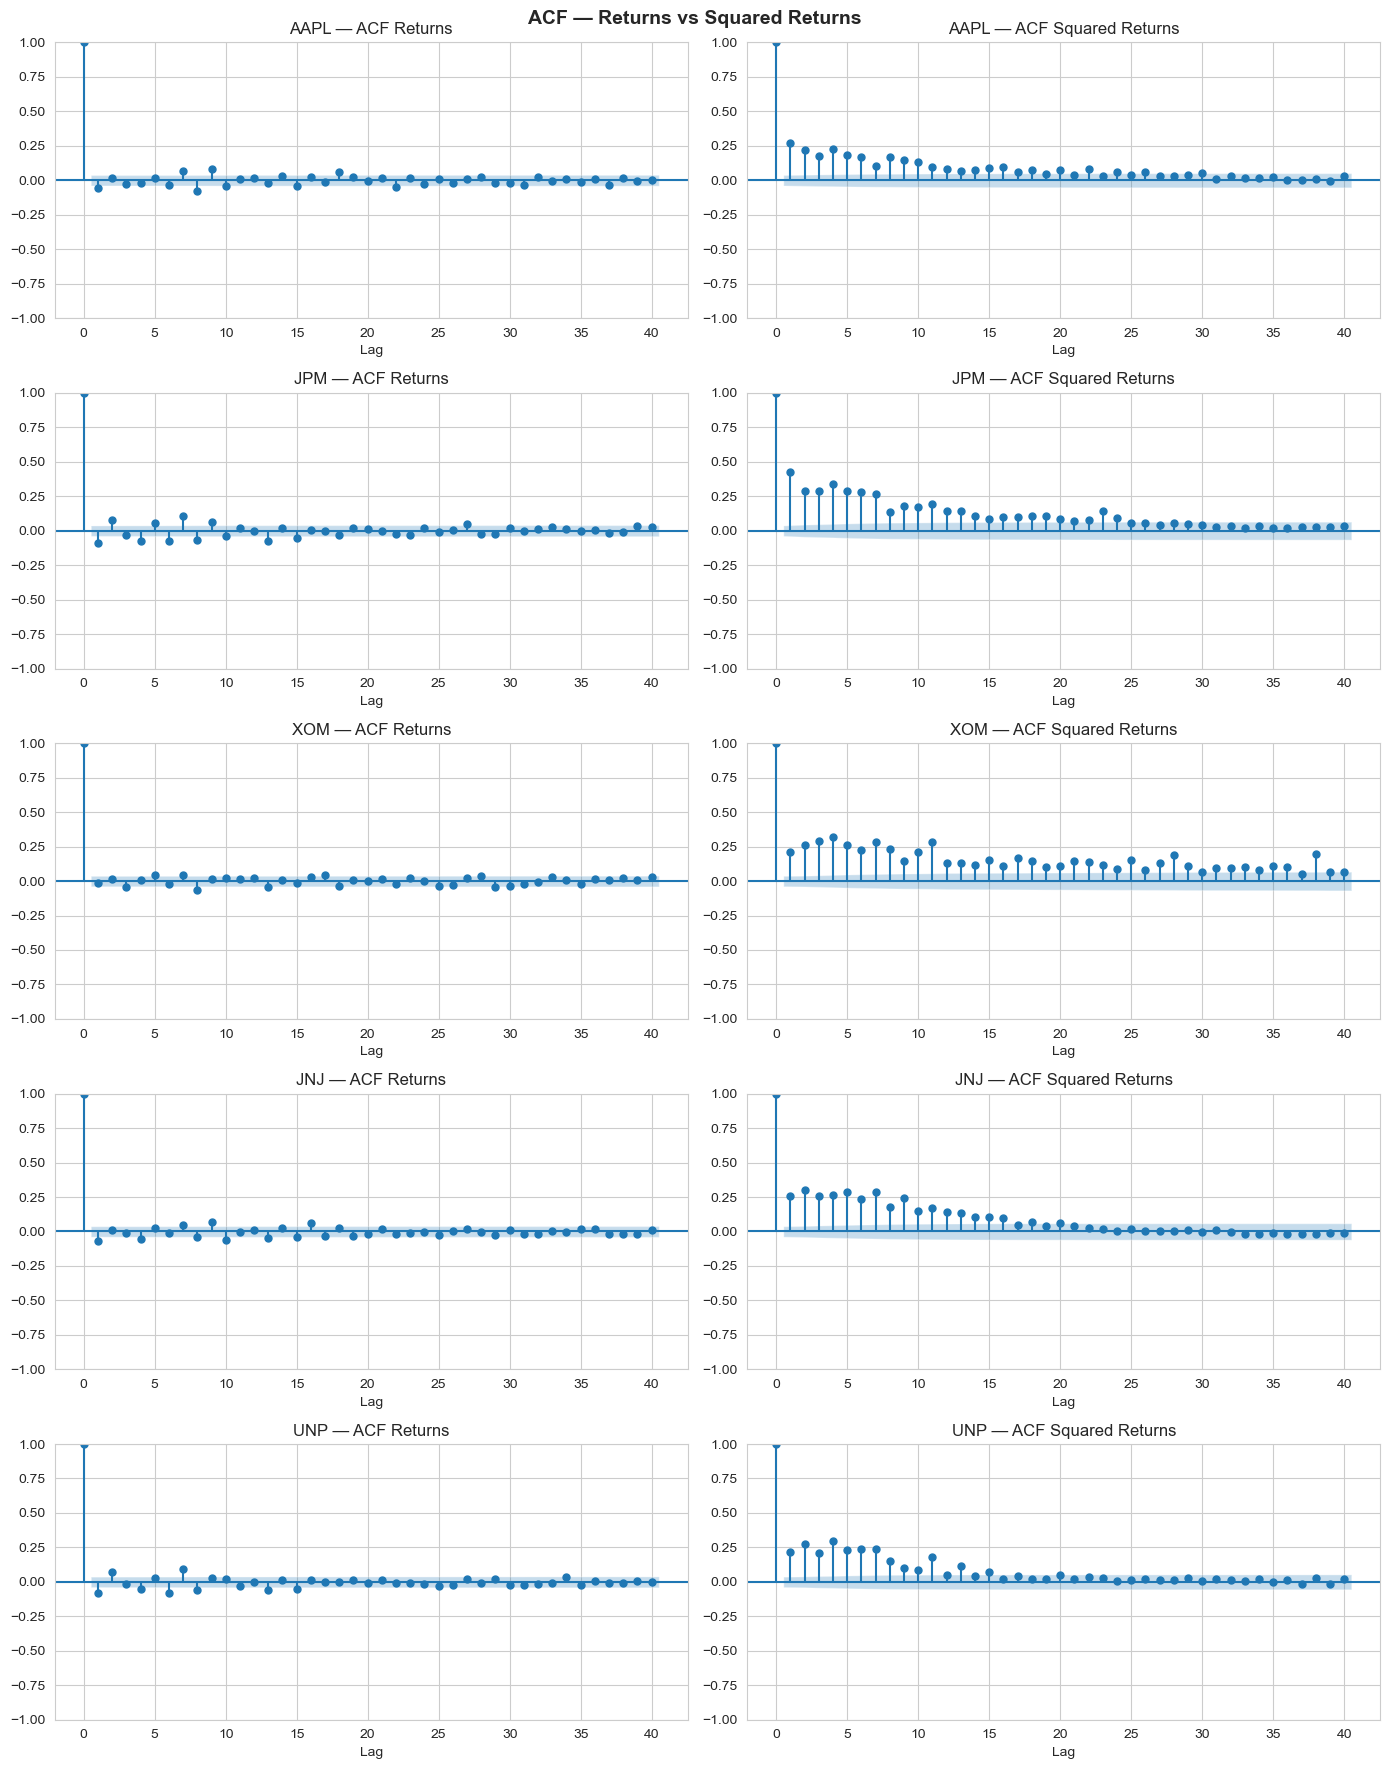

In [25]:
# ── 5. ACF of returns and squared returns ─────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for i, t in enumerate(TICKERS):
    rets = panel[panel.stock_id == t]["log_return"].dropna()

    plot_acf(rets,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{t} — ACF Returns")
    plot_acf(rets**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{t} — ACF Squared Returns")

    axes[i, 0].set_xlabel("Lag")
    axes[i, 1].set_xlabel("Lag")

fig.suptitle("ACF — Returns vs Squared Returns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

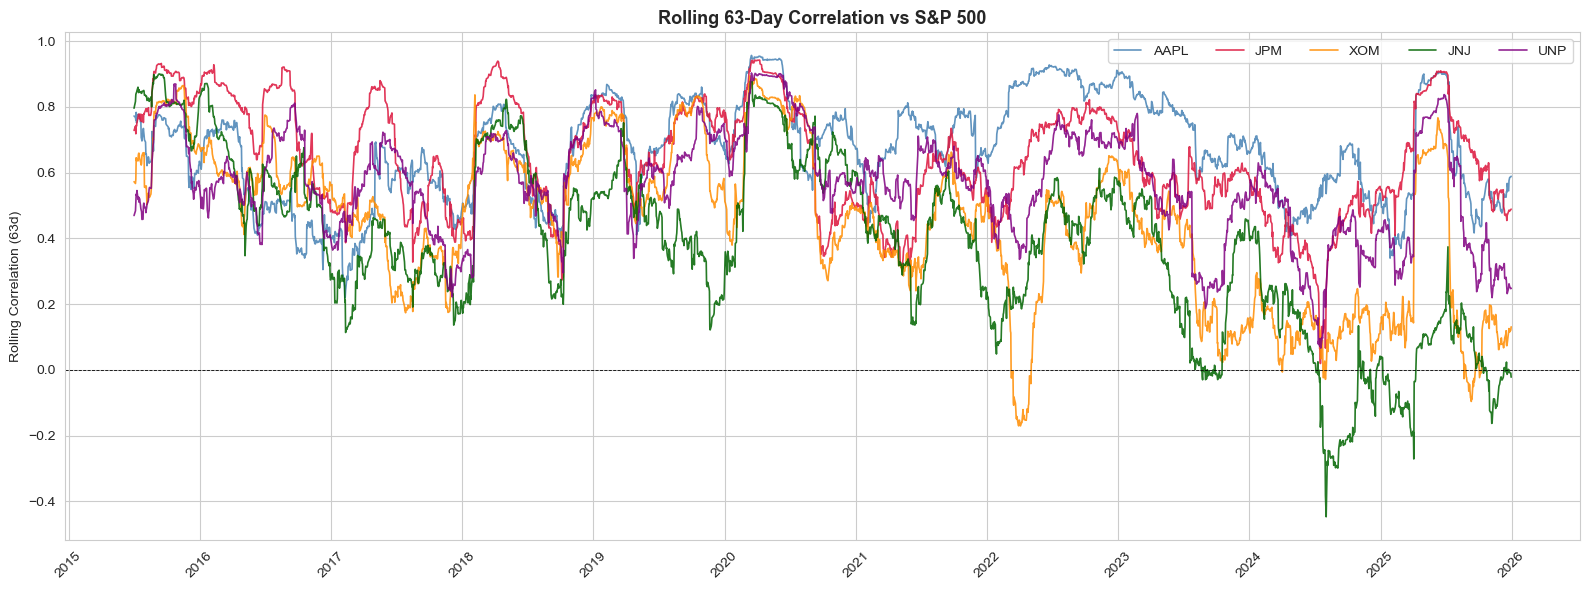

In [26]:
# ── 6. Rolling correlation of each stock vs SPX ────────────────────────────────
window = 63  # 1 quarter

fig, ax = plt.subplots(figsize=(16, 6))

colors_tickers = {"AAPL":"steelblue", "JPM":"crimson", "XOM":"darkorange",
                  "JNJ":"darkgreen",  "UNP":"purple"}

for t in TICKERS:
    stock_rets = panel[panel.stock_id == t].set_index("date")["log_return"]
    spx_rets   = panel[panel.stock_id == t].set_index("date")["SP500_ret"]
    rolling_corr = stock_rets.rolling(window).corr(spx_rets)
    ax.plot(rolling_corr.index, rolling_corr, label=t,
            color=colors_tickers[t], lw=1.2, alpha=0.85)

ax.axhline(0, color="black", lw=0.6, linestyle="--")
ax.set_ylabel("Rolling Correlation (63d)", fontsize=10)
ax.set_title("Rolling 63-Day Correlation vs S&P 500", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

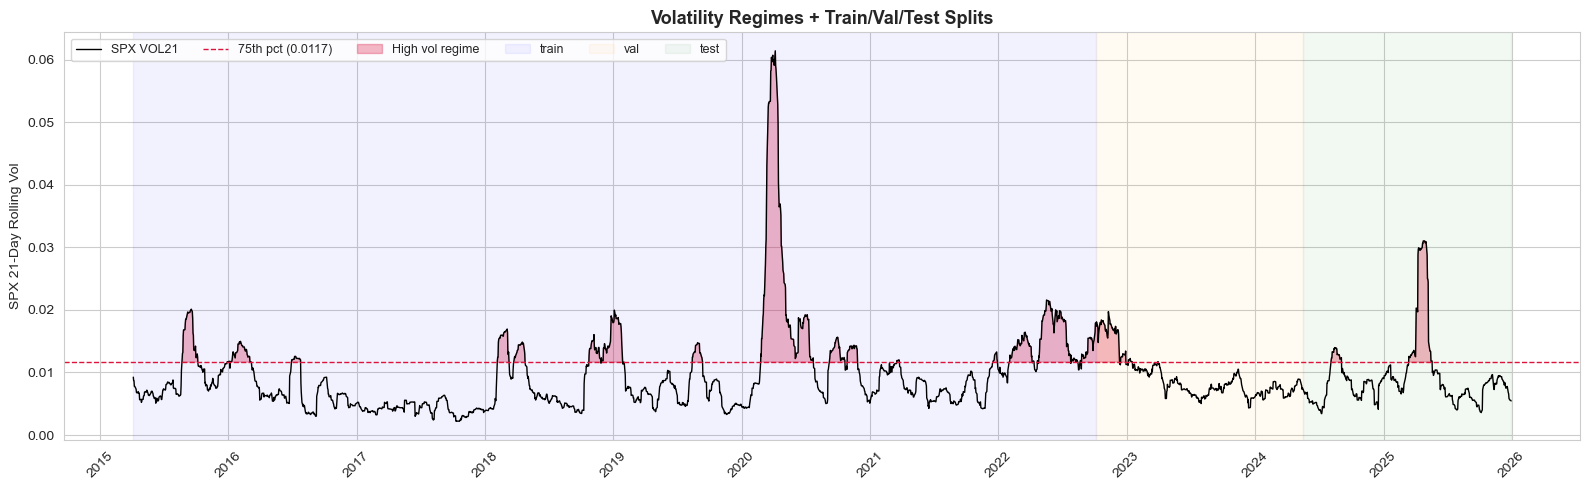

In [27]:
# ── 7. Volatility regime plot ──────────────────────────────────────────────────
spx_vol = panel[panel.stock_id == "AAPL"].set_index("date")["SP500_VOL21"]

# define high vol threshold as 75th percentile
threshold = spx_vol.quantile(0.75)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(spx_vol.index, spx_vol, color="black", lw=1.0, label="SPX VOL21")
ax.axhline(threshold, color="crimson", lw=1.0, linestyle="--", label=f"75th pct ({threshold:.4f})")
ax.fill_between(spx_vol.index, spx_vol, threshold,
                where=(spx_vol >= threshold),
                color="crimson", alpha=0.3, label="High vol regime")

# shade train/val/test regions
split_colors = {"train":"blue", "val":"orange", "test":"green"}
for split, color in split_colors.items():
    dates = panel[panel.split == split]["date"]
    ax.axvspan(dates.min(), dates.max(), alpha=0.05, color=color, label=split)

ax.set_ylabel("SPX 21-Day Rolling Vol", fontsize=10)
ax.set_title("Volatility Regimes + Train/Val/Test Splits", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=7, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# ── 8. Save panel to CSV ───────────────────────────────────────────────────────
panel.to_csv("tft_panel.csv", index=False)
print(f"Saved tft_panel.csv — {panel.shape[0]} rows x {panel.shape[1]} cols")

Saved tft_panel.csv — 13510 rows x 16 cols
